In [7]:
import pandas as pd
import math

In [15]:
actcoef_drug_water_benchmark = pd.read_csv('C:/Users/kverg/GDI-NN/data/solubility_cosolvents/benchmark_actcoef_drugs_water_systems.csv')
actcoef_drug_cosolvent_benchmark = pd.read_csv('C:/Users/kverg/GDI-NN/data/solubility_cosolvents/benchmark_actcoef_drugs_cosolvent_systems.csv')
solub_drug_water_benchmark = pd.read_csv('C:/Users/kverg/GDI-NN/data/solubility_cosolvents/benchmark_solubility_drugs_water_systems.csv')
solub_drug_cosolvent_benchmark = pd.read_csv('C:/Users/kverg/GDI-NN/data/solubility_cosolvents/benchmark_solubility_drugs_cosolvent_systems.csv')

In [41]:
solubility_product_water = solub_drug_water_benchmark.copy()
lngamma_col = []
for i in range(solubility_product_water.shape[0]):
    solute = solubility_product_water.iloc[i]['solute']
    lngamma = actcoef_drug_water_benchmark[actcoef_drug_water_benchmark['solute']==solute]['ln(gamma)_solute'].values[0]
    lngamma_col.append(lngamma)
solubility_product_water['ln(gamma)_solute'] = lngamma_col
solubility_product_water

,querry_solute_name,solvent_id,solvent,solvent_smiles,solvent_fileName,solute_id,solute,solute_smiles,solute_fileName,x1,x2,solute_smiles_canon,LogS,cosmo required?,ln(gamma)_solute
0,"1,3-Phenylenediamine",1,h2o,O,h2o_c0,0,"1,3-benzenediamine",Nc1cc(N)ccc1,"1,3-benzenediamine_c0",1,0,Nc1cccc(N)c1,0.342795,False,3.439712
1,"2,5-Furandicarboxylic acid",1,h2o,O,h2o_c0,1,"2,5-furandicarboxylicacid",OC(=O)c1oc(C(O)=O)cc1,"2,5-furandicarboxylicacid_c0",1,0,O=C(O)c1ccc(C(=O)O)o1,-2.193403,False,0.538528
2,2-(Diacetoxymethyl)-5-nitrofuran,1,h2o,O,h2o_c0,2,2-(diacetoxymethyl)-5-nitrofuran,CC(OC(OC(C)=O)c1oc(cc1)N(=O)=O)=O,2-(diacetoxymethyl)-5-nitrofuran_c0,1,0,CC(=O)OC(OC(C)=O)c1ccc([N+](=O)[O-])o1,NaN,True,10.548134
3,5-Fluorouracil,1,h2o,O,h2o_c0,3,5-fluorouracil,Fc1c[nH]c(=O)[nH]c1=O,5-fluorouracil_c0,1,0,O=c1[nH]cc(F)c(=O)[nH]1,-1.070000,False,1.129609
4,Acetaminophen,1,h2o,O,h2o_c0,4,4-hydroxyacetanilide,Oc1ccc(cc1)NC(C)=O,4-hydroxyacetanilide_c0,1,0,CC(=O)Nc1ccc(O)cc1,-1.030000,False,3.655793
5,Allantoin,1,h2o,O,h2o_c0,5,allantoin,O=C(N)NC1NC(=O)NC1=O,allantoin_c0,1,0,NC(=O)NC1NC(=O)NC1=O,-1.600000,False,-0.163614
6,Aspirin,1,h2o,O,h2o_c0,6,aspirin,CC(=O)Oc1ccccc1C(O)=O,aspirin_c0,1,0,CC(=O)Oc1ccccc1C(=O)O,-1.720000,False,5.517117
7,Benzoic acid,1,h2o,O,h2o_c0,7,benzoicacid,OC(=O)c1ccccc1,benzoicacid_c0,1,0,O=C(O)c1ccccc1,-1.550000,False,4.725750
8,Bifonazole,1,h2o,O,h2o_c0,8,bifonazole,c(cc1)ccc1C(n1ccnc1)c1ccc(cc1)c1ccccc1,bifonazole_c0,1,0,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1,-6.452508,False,12.419077
9,Carbendazim,1,h2o,O,h2o_c0,9,carbendazim,COC(=O)Nc1[nH]c2ccccc2n1,carbendazim_c0,1,0,COC(=O)Nc1nc2ccccc2[nH]1,NaN,True,6.870862


In [42]:
solubility_product_water = solubility_product_water.dropna(subset=['LogS'])
solubility_product_water = solubility_product_water.drop(columns=['cosmo required?'])
Ksp_col = []
for i in range(solubility_product_water.shape[0]):
    row = solubility_product_water.iloc[i]
    lngamma = row['ln(gamma)_solute']
    gamma = math.exp(lngamma)
    logS = row['LogS']
    S = math.pow(10,logS)
    Ksp = S*gamma
    Ksp_col.append(Ksp)
solubility_product_water['Ksp'] = Ksp_col
solubility_product_water

,querry_solute_name,solvent_id,solvent,solvent_smiles,solvent_fileName,solute_id,solute,solute_smiles,solute_fileName,x1,x2,solute_smiles_canon,LogS,ln(gamma)_solute,Ksp
0,"1,3-Phenylenediamine",1,h2o,O,h2o_c0,0,"1,3-benzenediamine",Nc1cc(N)ccc1,"1,3-benzenediamine_c0",1,0,Nc1cccc(N)c1,0.342795,3.439712,68.650409
1,"2,5-Furandicarboxylic acid",1,h2o,O,h2o_c0,1,"2,5-furandicarboxylicacid",OC(=O)c1oc(C(O)=O)cc1,"2,5-furandicarboxylicacid_c0",1,0,O=C(O)c1ccc(C(=O)O)o1,-2.193403,0.538528,0.010977
3,5-Fluorouracil,1,h2o,O,h2o_c0,3,5-fluorouracil,Fc1c[nH]c(=O)[nH]c1=O,5-fluorouracil_c0,1,0,O=c1[nH]cc(F)c(=O)[nH]1,-1.070000,1.129609,0.263380
4,Acetaminophen,1,h2o,O,h2o_c0,4,4-hydroxyacetanilide,Oc1ccc(cc1)NC(C)=O,4-hydroxyacetanilide_c0,1,0,CC(=O)Nc1ccc(O)cc1,-1.030000,3.655793,3.611527
5,Allantoin,1,h2o,O,h2o_c0,5,allantoin,O=C(N)NC1NC(=O)NC1=O,allantoin_c0,1,0,NC(=O)NC1NC(=O)NC1=O,-1.600000,-0.163614,0.021328
6,Aspirin,1,h2o,O,h2o_c0,6,aspirin,CC(=O)Oc1ccccc1C(O)=O,aspirin_c0,1,0,CC(=O)Oc1ccccc1C(=O)O,-1.720000,5.517117,4.743005
7,Benzoic acid,1,h2o,O,h2o_c0,7,benzoicacid,OC(=O)c1ccccc1,benzoicacid_c0,1,0,O=C(O)c1ccccc1,-1.550000,4.725750,3.179560
8,Bifonazole,1,h2o,O,h2o_c0,8,bifonazole,c(cc1)ccc1C(n1ccnc1)c1ccc(cc1)c1ccccc1,bifonazole_c0,1,0,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1,-6.452508,12.419077,0.087303
10,Coumarin,1,h2o,O,h2o_c0,10,2h-1-benzopyran-2-one,O=C1C=Cc2ccccc2O1,2h-1-benzopyran-2-one_c0,1,0,O=c1ccc2ccccc2o1,-1.890000,5.754198,4.064587
11,Dibenzoylmethane,1,h2o,O,h2o_c0,11,"1,3-diphenyl-1,3-propanedione",O=C(CC(=O)c1ccccc1)c1ccccc1,"1,3-diphenyl-1,3-propanedione_c0",1,0,O=C(CC(=O)c1ccccc1)c1ccccc1,-5.657902,10.850939,0.113397


In [43]:
solubility_product_water = solubility_product_water.reset_index(drop=True)
solubility_product_water

,querry_solute_name,solvent_id,solvent,solvent_smiles,solvent_fileName,solute_id,solute,solute_smiles,solute_fileName,x1,x2,solute_smiles_canon,LogS,ln(gamma)_solute,Ksp
0,"1,3-Phenylenediamine",1,h2o,O,h2o_c0,0,"1,3-benzenediamine",Nc1cc(N)ccc1,"1,3-benzenediamine_c0",1,0,Nc1cccc(N)c1,0.342795,3.439712,68.650409
1,"2,5-Furandicarboxylic acid",1,h2o,O,h2o_c0,1,"2,5-furandicarboxylicacid",OC(=O)c1oc(C(O)=O)cc1,"2,5-furandicarboxylicacid_c0",1,0,O=C(O)c1ccc(C(=O)O)o1,-2.193403,0.538528,0.010977
2,5-Fluorouracil,1,h2o,O,h2o_c0,3,5-fluorouracil,Fc1c[nH]c(=O)[nH]c1=O,5-fluorouracil_c0,1,0,O=c1[nH]cc(F)c(=O)[nH]1,-1.070000,1.129609,0.263380
3,Acetaminophen,1,h2o,O,h2o_c0,4,4-hydroxyacetanilide,Oc1ccc(cc1)NC(C)=O,4-hydroxyacetanilide_c0,1,0,CC(=O)Nc1ccc(O)cc1,-1.030000,3.655793,3.611527
4,Allantoin,1,h2o,O,h2o_c0,5,allantoin,O=C(N)NC1NC(=O)NC1=O,allantoin_c0,1,0,NC(=O)NC1NC(=O)NC1=O,-1.600000,-0.163614,0.021328
5,Aspirin,1,h2o,O,h2o_c0,6,aspirin,CC(=O)Oc1ccccc1C(O)=O,aspirin_c0,1,0,CC(=O)Oc1ccccc1C(=O)O,-1.720000,5.517117,4.743005
6,Benzoic acid,1,h2o,O,h2o_c0,7,benzoicacid,OC(=O)c1ccccc1,benzoicacid_c0,1,0,O=C(O)c1ccccc1,-1.550000,4.725750,3.179560
7,Bifonazole,1,h2o,O,h2o_c0,8,bifonazole,c(cc1)ccc1C(n1ccnc1)c1ccc(cc1)c1ccccc1,bifonazole_c0,1,0,c1ccc(-c2ccc(C(c3ccccc3)n3ccnc3)cc2)cc1,-6.452508,12.419077,0.087303
8,Coumarin,1,h2o,O,h2o_c0,10,2h-1-benzopyran-2-one,O=C1C=Cc2ccccc2O1,2h-1-benzopyran-2-one_c0,1,0,O=c1ccc2ccccc2o1,-1.890000,5.754198,4.064587
9,Dibenzoylmethane,1,h2o,O,h2o_c0,11,"1,3-diphenyl-1,3-propanedione",O=C(CC(=O)c1ccccc1)c1ccccc1,"1,3-diphenyl-1,3-propanedione_c0",1,0,O=C(CC(=O)c1ccccc1)c1ccccc1,-5.657902,10.850939,0.113397


In [25]:
solubility_product_cosolvent = solub_drug_cosolvent_benchmark.copy()
solubility_product_cosolvent

,querry_solute_name,querry_solvent_1_name,querry_solvent_2_name,solute_smiles_canon,solvent_1_smiles_canon,solvent_2_smiles_canon,Temperature (K),LogS,x1,x2,solute,solvent_1,solvent_2
0,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.706554,0.158,0.842,"1,3-benzenediamine",acetonitrile,h2o
1,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.731266,0.227,0.773,"1,3-benzenediamine",acetonitrile,h2o
2,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.750182,0.305,0.695,"1,3-benzenediamine",acetonitrile,h2o
3,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.760835,0.397,0.603,"1,3-benzenediamine",acetonitrile,h2o
4,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.766927,0.506,0.494,"1,3-benzenediamine",acetonitrile,h2o
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Thiabendazole,Methanol,Water,N1=CSC=C1C2=NC3=CC=CC=C3N2,CO,O,298.15,-0.039222,0.835,0.165,thiabendazole,methanol,h2o
446,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.165377,0.281,0.719,4-hydroxyacetanilide,ethanol,h2o
447,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.280612,0.610,0.390,4-hydroxyacetanilide,ethanol,h2o
448,Aspirin,Ethanol,Water,O=C(O)C=1C=CC=CC1OC(=O)C,CCO,O,298.15,1.001880,0.281,0.719,aspirin,ethanol,h2o


In [46]:
solubility_product_cosolvent = solub_drug_cosolvent_benchmark.copy()
lngamma_solvent_1_col = []
lngamma_solvent_2_col = []
lngamma_solute_col = []
for i in range(solubility_product_cosolvent.shape[0]):
    solute = solubility_product_cosolvent.iloc[i]['solute']
    solvent_1 = solubility_product_cosolvent.iloc[i]['solvent_1']
    solvent_2 = solubility_product_cosolvent.iloc[i]['solvent_2']
    x1 = solubility_product_cosolvent.iloc[i]['x1']
    x2 = solubility_product_cosolvent.iloc[i]['x2']
    system = actcoef_drug_cosolvent_benchmark[(actcoef_drug_cosolvent_benchmark['solute']==solute) & (actcoef_drug_cosolvent_benchmark['solvent_1']==solvent_1) & (actcoef_drug_cosolvent_benchmark['solvent_2']==solvent_2) & (actcoef_drug_cosolvent_benchmark['x1']==x1) & (actcoef_drug_cosolvent_benchmark['x2']==x2)]
    lngamma_solvent_1 = system['ln(gamma)_solvent_1'].values[0]
    lngamma_solvent_2 = system['ln(gamma)_solvent_2'].values[0]
    lngamma_solute = system['ln(gamma)_solute'].values[0]
    lngamma_solvent_1_col.append(lngamma_solvent_1)
    lngamma_solvent_2_col.append(lngamma_solvent_2)
    lngamma_solute_col.append(lngamma_solute)
solubility_product_cosolvent['ln(gamma)_solvent_1'] = lngamma_solvent_1_col
solubility_product_cosolvent['ln(gamma)_solvent_2'] = lngamma_solvent_2_col
solubility_product_cosolvent['ln(gamma)_solute'] = lngamma_solute_col
solubility_product_cosolvent


,querry_solute_name,querry_solvent_1_name,querry_solvent_2_name,solute_smiles_canon,solvent_1_smiles_canon,solvent_2_smiles_canon,Temperature (K),LogS,x1,x2,solute,solvent_1,solvent_2,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute
0,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.706554,0.158,0.842,"1,3-benzenediamine",acetonitrile,h2o,1.235025,0.055579,1.552940
1,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.731266,0.227,0.773,"1,3-benzenediamine",acetonitrile,h2o,0.993442,0.112954,0.954062
2,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.750182,0.305,0.695,"1,3-benzenediamine",acetonitrile,h2o,0.771687,0.192996,0.438016
3,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.760835,0.397,0.603,"1,3-benzenediamine",acetonitrile,h2o,0.566656,0.303444,-0.010982
4,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.766927,0.506,0.494,"1,3-benzenediamine",acetonitrile,h2o,0.382111,0.454843,-0.387182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Thiabendazole,Methanol,Water,N1=CSC=C1C2=NC3=CC=CC=C3N2,CO,O,298.15,-0.039222,0.835,0.165,thiabendazole,methanol,h2o,0.001680,0.188208,1.039955
446,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.165377,0.281,0.719,4-hydroxyacetanilide,ethanol,h2o,0.293643,0.186900,0.753085
447,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.280612,0.610,0.390,4-hydroxyacetanilide,ethanol,h2o,0.036326,0.364802,-0.052755
448,Aspirin,Ethanol,Water,O=C(O)C=1C=CC=CC1OC(=O)C,CCO,O,298.15,1.001880,0.281,0.719,aspirin,ethanol,h2o,0.293643,0.186900,1.207643


In [47]:
Ksp_from_water_col = []
for i in range(solubility_product_cosolvent.shape[0]):
    solute = solubility_product_cosolvent.iloc[i]['solute']
    Ksp_from_water = solubility_product_water[solubility_product_water['solute']==solute]['Ksp']
    if Ksp_from_water.empty:
        Ksp_from_water = None
    else:
        Ksp_from_water = Ksp_from_water.values[0]
    Ksp_from_water_col.append(Ksp_from_water)
solubility_product_cosolvent['Ksp_from_water'] = Ksp_from_water_col
solubility_product_cosolvent

,querry_solute_name,querry_solvent_1_name,querry_solvent_2_name,solute_smiles_canon,solvent_1_smiles_canon,solvent_2_smiles_canon,Temperature (K),LogS,x1,x2,solute,solvent_1,solvent_2,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,Ksp_from_water
0,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.706554,0.158,0.842,"1,3-benzenediamine",acetonitrile,h2o,1.235025,0.055579,1.552940,68.650409
1,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.731266,0.227,0.773,"1,3-benzenediamine",acetonitrile,h2o,0.993442,0.112954,0.954062,68.650409
2,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.750182,0.305,0.695,"1,3-benzenediamine",acetonitrile,h2o,0.771687,0.192996,0.438016,68.650409
3,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.760835,0.397,0.603,"1,3-benzenediamine",acetonitrile,h2o,0.566656,0.303444,-0.010982,68.650409
4,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.766927,0.506,0.494,"1,3-benzenediamine",acetonitrile,h2o,0.382111,0.454843,-0.387182,68.650409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Thiabendazole,Methanol,Water,N1=CSC=C1C2=NC3=CC=CC=C3N2,CO,O,298.15,-0.039222,0.835,0.165,thiabendazole,methanol,h2o,0.001680,0.188208,1.039955,0.678939
446,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.165377,0.281,0.719,4-hydroxyacetanilide,ethanol,h2o,0.293643,0.186900,0.753085,3.611527
447,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.280612,0.610,0.390,4-hydroxyacetanilide,ethanol,h2o,0.036326,0.364802,-0.052755,3.611527
448,Aspirin,Ethanol,Water,O=C(O)C=1C=CC=CC1OC(=O)C,CCO,O,298.15,1.001880,0.281,0.719,aspirin,ethanol,h2o,0.293643,0.186900,1.207643,4.743005


In [48]:
solubility_product_cosolvent = solubility_product_cosolvent.dropna(subset=['Ksp_from_water'])
solubility_product_cosolvent = solubility_product_cosolvent.reset_index(drop=True)
solubility_product_cosolvent

,querry_solute_name,querry_solvent_1_name,querry_solvent_2_name,solute_smiles_canon,solvent_1_smiles_canon,solvent_2_smiles_canon,Temperature (K),LogS,x1,x2,solute,solvent_1,solvent_2,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,Ksp_from_water
0,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.706554,0.158,0.842,"1,3-benzenediamine",acetonitrile,h2o,1.235025,0.055579,1.552940,68.650409
1,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.731266,0.227,0.773,"1,3-benzenediamine",acetonitrile,h2o,0.993442,0.112954,0.954062,68.650409
2,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.750182,0.305,0.695,"1,3-benzenediamine",acetonitrile,h2o,0.771687,0.192996,0.438016,68.650409
3,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.760835,0.397,0.603,"1,3-benzenediamine",acetonitrile,h2o,0.566656,0.303444,-0.010982,68.650409
4,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.766927,0.506,0.494,"1,3-benzenediamine",acetonitrile,h2o,0.382111,0.454843,-0.387182,68.650409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,Thiabendazole,Methanol,Water,N1=CSC=C1C2=NC3=CC=CC=C3N2,CO,O,298.15,-0.039222,0.835,0.165,thiabendazole,methanol,h2o,0.001680,0.188208,1.039955,0.678939
302,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.165377,0.281,0.719,4-hydroxyacetanilide,ethanol,h2o,0.293643,0.186900,0.753085,3.611527
303,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.280612,0.610,0.390,4-hydroxyacetanilide,ethanol,h2o,0.036326,0.364802,-0.052755,3.611527
304,Aspirin,Ethanol,Water,O=C(O)C=1C=CC=CC1OC(=O)C,CCO,O,298.15,1.001880,0.281,0.719,aspirin,ethanol,h2o,0.293643,0.186900,1.207643,4.743005


In [53]:
calculated_logS_col = []
Ksp_from_cosolvent_col = []
for i in range(solubility_product_cosolvent.shape[0]):
    row = solubility_product_cosolvent.iloc[i]
    lngamma_solute = row['ln(gamma)_solute']
    gamma_solute = math.exp(lngamma_solute)
    Ksp_from_water = row['Ksp_from_water']
    calc_S = Ksp_from_water/gamma_solute
    calc_logS = math.log10(calc_S)
    calculated_logS_col.append(calc_logS)
    logS = row['LogS']
    S = math.pow(10,logS)
    Ksp_from_cosolvent = S*gamma_solute
    Ksp_from_cosolvent_col.append(Ksp_from_cosolvent)
solubility_product_cosolvent['calculated_LogS'] = calculated_logS_col
solubility_product_cosolvent['Ksp_from_cosolvent'] = Ksp_from_cosolvent_col
solubility_product_cosolvent

,querry_solute_name,querry_solvent_1_name,querry_solvent_2_name,solute_smiles_canon,solvent_1_smiles_canon,solvent_2_smiles_canon,Temperature (K),LogS,x1,x2,solute,solvent_1,solvent_2,ln(gamma)_solvent_1,ln(gamma)_solvent_2,ln(gamma)_solute,Ksp_from_water,calculated_LogS,Ksp_from_cosolvent
0,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.706554,0.158,0.842,"1,3-benzenediamine",acetonitrile,h2o,1.235025,0.055579,1.552940,68.650409,1.162210,240.429352
1,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.731266,0.227,0.773,"1,3-benzenediamine",acetonitrile,h2o,0.993442,0.112954,0.954062,68.650409,1.422299,139.833150
2,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.750182,0.305,0.695,"1,3-benzenediamine",acetonitrile,h2o,0.771687,0.192996,0.438016,68.650409,1.646415,87.178650
3,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.760835,0.397,0.603,"1,3-benzenediamine",acetonitrile,h2o,0.566656,0.303444,-0.010982,68.650409,1.841413,57.024990
4,"1,3-Phenylenediamine",Acetonitrile,Water,NC1=CC=CC(N)=C1,CC#N,O,298.15,1.766927,0.506,0.494,"1,3-benzenediamine",acetonitrile,h2o,0.382111,0.454843,-0.387182,68.650409,2.004794,39.698660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,Thiabendazole,Methanol,Water,N1=CSC=C1C2=NC3=CC=CC=C3N2,CO,O,298.15,-0.039222,0.835,0.165,thiabendazole,methanol,h2o,0.001680,0.188208,1.039955,0.678939,-0.619816,2.584785
302,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.165377,0.281,0.719,4-hydroxyacetanilide,ethanol,h2o,0.293643,0.186900,0.753085,3.611527,0.230630,31.076883
303,Acetaminophen,Ethanol,Water,O=C(NC1=CC=C(O)C=C1)C,CCO,O,298.15,1.280612,0.610,0.390,4-hydroxyacetanilide,ethanol,h2o,0.036326,0.364802,-0.052755,3.611527,0.580602,18.100918
304,Aspirin,Ethanol,Water,O=C(O)C=1C=CC=CC1OC(=O)C,CCO,O,298.15,1.001880,0.281,0.719,aspirin,ethanol,h2o,0.293643,0.186900,1.207643,4.743005,0.151581,33.601016


In [102]:
solubility_product_cosolvent.to_csv('C:/Users/kverg/GDI-NN/data/solubility_cosolvents/benchmark_solubility_product.csv', index=False)

0.6170009208429128
0.4178665262552076
[-5, -1.472331710433125]
[4, 2.288467025863743]


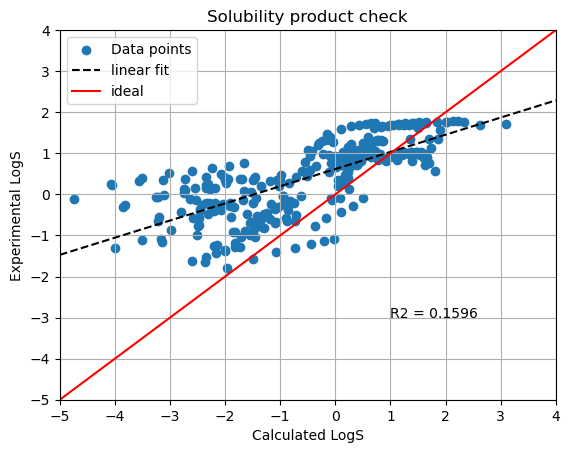

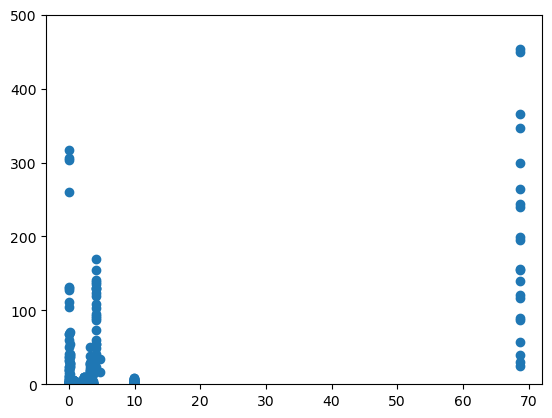

In [101]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

R2_logS = r2_score(solubility_product_cosolvent['calculated_LogS'], solubility_product_cosolvent['LogS'])

calculated_logS_array = np.array(solubility_product_cosolvent['calculated_LogS'].tolist()).reshape(-1, 1)
logS_array = np.array(solubility_product_cosolvent['LogS'].tolist())

lm = LinearRegression()
lm.fit(calculated_logS_array, logS_array)

intercept = float(lm.intercept_)
slope = float(lm.coef_[0])
print(intercept)
print(slope)

initial_point = [-5,-5*slope+intercept]
final_point = [4,4*slope+intercept]
print(initial_point)
print(final_point)

fig_logS, ax_logS = plt.subplots()
ax_logS.scatter(x=solubility_product_cosolvent['calculated_LogS'], y=solubility_product_cosolvent['LogS'])
ax_logS.plot([initial_point[0],final_point[0]], [initial_point[1],final_point[1]], 'k--')
ax_logS.plot([-5,4], [-5,4], 'r-')
text = 'R2 = {:.4f}'.format(R2_logS)
ax_logS.set_ylim(-5,4)
ax_logS.set_xlim(-5,4)
ax_logS.text(x=1, y=-3, s=text)
ax_logS.set_title('Solubility product check')
ax_logS.set_xlabel('Calculated LogS')
ax_logS.set_ylabel('Experimental LogS')
ax_logS.grid()
ax_logS.legend(['Data points', 'linear fit', 'ideal'])
fig_logS.savefig('C:/Users/kverg/GDI-NN/Plots/Solubility_product_check.png',format='png')
fig_logS.savefig('C:/Users/kverg/GDI-NN/Plots/Solubility_product_check.svg',format='svg')
plt.show()
fig_Ksp, ax_Ksp = plt.subplots()
ax_Ksp.scatter(x=solubility_product_cosolvent['Ksp_from_water'], y=solubility_product_cosolvent['Ksp_from_cosolvent'])
ax_Ksp.set_ylim(0,500)

plt.show()

In [37]:
solubility_product_cosolvent.to_csv('C:/Users/kverg/GDI-NN/data/solubility_cosolvents/benchmark_solubility_product_cosolvent.csv')